# Phase 3 clean regime comparison

Purpose: reproduce the clean comparison between the restored Phase 2 final QRC, Phase 3 RF-QRC ring, and ESN reference.

This notebook writes only to root-level `results/tables/` and `results/figures/`.

In [1]:
from pathlib import Path
import subprocess
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, mean_squared_error

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

EXPECTED_REPO_NAME = "qpitome-qrc-volatility"

def find_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if p.name == EXPECTED_REPO_NAME and (p / ".git").exists() and (p / "scripts").is_dir():
            return p
    raise RuntimeError(f"Could not find repo root named {EXPECTED_REPO_NAME!r} from {cwd}")

ROOT = find_repo_root()
TABLE_DIR = ROOT / "results" / "tables"
FIG_DIR = ROOT / "results" / "figures"
DATA_PATH = ROOT / "data" / "processed" / "phase2_spy_vix_volatility.csv"
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Repo root:", ROOT)
print("Tables:", TABLE_DIR)
print("Figures:", FIG_DIR)
assert ROOT.name == EXPECTED_REPO_NAME
assert not str(TABLE_DIR).endswith("notebooks/results/tables")

Repo root: /Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility
Tables: /Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility/results/tables
Figures: /Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility/results/figures


## 1. Ensure required prediction exports exist

In [2]:
AUTO_RESTORE_OLD_EXPORTERS = True
AUTO_RUN_MISSING_OUTPUTS = True

required = {
    "Phase 2 final QRC predictions": TABLE_DIR / "phase2_qrc_final_encoding_readout_predictions.csv",
    "ESN predictions": TABLE_DIR / "phase2_esn_predictions.csv",
    "RF-QRC predictions": TABLE_DIR / "phase3_rf_qrc_tail_probe_predictions_level_rate.csv",
}

def run_cmd(cmd, *, check=True):
    print("$", " ".join(str(x) for x in cmd))
    result = subprocess.run([str(x) for x in cmd], cwd=ROOT, text=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT)
    print(result.stdout)
    if check and result.returncode != 0:
        raise RuntimeError(f"Command failed with exit code {result.returncode}: {cmd}")
    return result

if AUTO_RESTORE_OLD_EXPORTERS:
    if not (ROOT / "scripts" / "export_final_qrc_predictions.py").exists():
        run_cmd(["git", "checkout", "99b5bab", "--", "scripts/export_final_qrc_predictions.py"])
    if not (ROOT / "scripts" / "export_esn_predictions.py").exists():
        run_cmd(["git", "checkout", "99b5bab", "--", "scripts/export_esn_predictions.py"])

if AUTO_RUN_MISSING_OUTPUTS:
    if not required["Phase 2 final QRC predictions"].exists():
        run_cmd([sys.executable, "scripts/export_final_qrc_predictions.py"])
    if not required["ESN predictions"].exists():
        run_cmd([sys.executable, "scripts/export_esn_predictions.py"])
    if not required["RF-QRC predictions"].exists():
        run_cmd([sys.executable, "scripts/run_phase3_rf_qrc_tail_probe.py", "--input-mode", "level_rate"])

for label, path in required.items():
    print(label, "OK" if path.exists() else "MISSING", path)

Phase 2 final QRC predictions OK /Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility/results/tables/phase2_qrc_final_encoding_readout_predictions.csv
ESN predictions OK /Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility/results/tables/phase2_esn_predictions.csv
RF-QRC predictions OK /Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility/results/tables/phase3_rf_qrc_tail_probe_predictions_level_rate.csv


## 2. Rebuild the original Phase 2 stress timeline and thresholds

In [3]:
if not DATA_PATH.exists():
    run_cmd([sys.executable, "scripts/prepare_phase2_spy_vix_dataset.py"])

TARGET = "future_rv_20d"
df = pd.read_csv(DATA_PATH, parse_dates=["date"]).sort_values("date").reset_index(drop=True)

def chronological_split_by_date(frame: pd.DataFrame):
    train = frame[frame["date"] <= "2014-12-31"].copy()
    val = frame[(frame["date"] >= "2015-01-01") & (frame["date"] <= "2019-12-31")].copy()
    test = frame[frame["date"] >= "2020-01-01"].copy()
    if min(len(train), len(val), len(test)) == 0:
        n = len(frame)
        train = frame.iloc[: int(0.70 * n)].copy()
        val = frame.iloc[int(0.70 * n) : int(0.85 * n)].copy()
        test = frame.iloc[int(0.85 * n) :].copy()
    return train, val, test

train_df, val_df, test_df = chronological_split_by_date(df)
thresholds = {
    "q80": float(train_df[TARGET].quantile(0.80)),
    "q90": float(train_df[TARGET].quantile(0.90)),
    "q95": float(train_df[TARGET].quantile(0.95)),
}
print("Split sizes:", len(train_df), len(val_df), len(test_df))
print("Train thresholds:", thresholds)

def make_stress_features(frame: pd.DataFrame, train_ref: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy().reset_index(drop=True)
    out["spy_selloff_stress"] = -out["spy_log_return"]
    out["spy_oc_selloff_stress"] = -out.get("spy_log_oc_return", out["spy_log_return"])

    if "spy_drawdown_20d" in out.columns:
        drawdown_col = "spy_drawdown_20d"
    elif "spy_drawdown" in out.columns:
        drawdown_col = "spy_drawdown"
    else:
        drawdown_col = None

    if drawdown_col is not None:
        draw_train = train_ref[drawdown_col]
        out["drawdown_stress"] = -out[drawdown_col] if draw_train.median() < 0 else out[drawdown_col]
    else:
        out["drawdown_stress"] = 0.0

    out["volume_stress"] = out["spy_log_volume_change"].abs() if "spy_log_volume_change" in out.columns else 0.0
    out["vix_level_stress"] = out["vix_close"] if "vix_close" in out.columns else 0.0
    out["vix_change_stress"] = np.maximum(out["vix_log_change"], 0.0) if "vix_log_change" in out.columns else 0.0
    out["vix_range_stress"] = out["vix_log_hl_range"] if "vix_log_hl_range" in out.columns else 0.0
    out["realized_vol_stress"] = out["rv_20d"] if "rv_20d" in out.columns else 0.0
    return out

stress_all = make_stress_features(df, train_df)
stress_train = stress_all.loc[train_df.index]

flag_source = {
    "flag_realized_vol": "realized_vol_stress",
    "flag_vix_level": "vix_level_stress",
    "flag_vix_range": "vix_range_stress",
    "flag_drawdown": "drawdown_stress",
    "flag_selloff": "spy_selloff_stress",
    "flag_volume": "volume_stress",
}
if "rv_slope_5_20" in stress_all.columns:
    flag_source["flag_vol_acceleration"] = "rv_slope_5_20"

flag_thresholds = {flag: float(stress_train[src].quantile(0.80)) for flag, src in flag_source.items()}

timeline = stress_all[["date", TARGET]].copy()
timeline["future_high_vol_event_q80"] = timeline[TARGET] > thresholds["q80"]
timeline["future_extreme_vol_event_q90"] = timeline[TARGET] > thresholds["q90"]
timeline["future_crisis_candidate_q95"] = timeline[TARGET] > thresholds["q95"]

for flag, src in flag_source.items():
    timeline[flag] = stress_all[src] > flag_thresholds[flag]

rally_thr = float(train_df["spy_log_return"].quantile(0.70))
selloff_thr = float(train_df["spy_log_return"].quantile(0.30))
timeline["direction_tag"] = "neutral"
timeline.loc[df["spy_log_return"] >= rally_thr, "direction_tag"] = "rally"
timeline.loc[df["spy_log_return"] <= selloff_thr, "direction_tag"] = "selloff"

timeline = timeline[timeline["date"].isin(test_df["date"])].reset_index(drop=True)
display(timeline.head())

Split sizes: 5459 1258 1058
Train thresholds: {'q80': 0.2125594115019885, 'q90': 0.27372979993114094, 'q95': 0.32594437578877844}


,date,future_rv_20d,future_high_vol_event_q80,future_extreme_vol_event_q90,future_crisis_candidate_q95,flag_realized_vol,flag_vix_level,flag_vix_range,flag_drawdown,flag_selloff,flag_volume,flag_vol_acceleration,direction_tag
0,2020-01-02,0.117560,False,False,False,False,False,True,False,False,False,False,rally
1,2020-01-03,0.117399,False,False,False,False,False,True,False,True,False,False,selloff
2,2020-01-06,0.128385,False,False,False,False,False,True,False,False,False,False,neutral
3,2020-01-07,0.134328,False,False,False,False,False,False,False,False,False,False,neutral
4,2020-01-08,0.133529,False,False,False,False,False,True,False,False,False,False,rally


## 3. Load common prediction table

In [4]:
phase2_qrc = pd.read_csv(TABLE_DIR / "phase2_qrc_final_encoding_readout_predictions.csv", parse_dates=["date"])
rf_qrc = pd.read_csv(TABLE_DIR / "phase3_rf_qrc_tail_probe_predictions_level_rate.csv", parse_dates=["date"])
esn = pd.read_csv(TABLE_DIR / "phase2_esn_predictions.csv", parse_dates=["date"])

qrc_col = "qrc_pred_future_rv_20d"
rf_col = "rf_qrc_second_encode_ring_level_rate_pred"
esn_col = "esn_pred_future_rv_20d"

phase2_qrc = phase2_qrc[["date", qrc_col]].copy()
rf_qrc = rf_qrc[rf_qrc["split"].eq("test")][["date", rf_col]].copy()
esn = esn[["date", esn_col]].copy()

merged_raw = (
    timeline[["date", TARGET]]
    .merge(phase2_qrc, on="date", how="inner")
    .merge(rf_qrc, on="date", how="inner")
    .merge(esn, on="date", how="inner")
    .sort_values("date")
    .reset_index(drop=True)
)
print("Common test rows:", len(merged_raw))
display(merged_raw.head())

Common test rows: 1019


,date,future_rv_20d,qrc_pred_future_rv_20d,rf_qrc_second_encode_ring_level_rate_pred,esn_pred_future_rv_20d
0,2020-02-28,0.923201,0.168038,0.312541,0.302564
1,2020-03-02,0.917891,0.179526,0.345127,0.278501
2,2020-03-03,0.913637,0.200856,0.363067,0.336297
3,2020-03-04,0.916564,0.158109,0.362964,0.291668
4,2020-03-05,0.912276,0.170180,0.409286,0.337469


## 4. Raw forecast metrics

In [5]:
def repo_qlike(y_true, y_pred, eps=1e-12):
    target = np.maximum(np.asarray(y_true, dtype=float) ** 2, eps)
    pred = np.maximum(np.asarray(y_pred, dtype=float) ** 2, eps)
    return float(np.mean(np.log(pred) + target / pred))

def mz_metrics(y_true, y_pred):
    y = np.asarray(y_true, dtype=float)
    x = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y) & np.isfinite(x)
    y = y[mask]
    x = x[mask]
    X = np.column_stack([np.ones_like(x), x])
    alpha, beta = np.linalg.lstsq(X, y, rcond=None)[0]
    fitted = alpha + beta * x
    ss_res = float(np.sum((y - fitted) ** 2))
    ss_tot = float(np.sum((y - y.mean()) ** 2))
    return float(alpha), float(beta), float(1 - ss_res / ss_tot)

def raw_score(name, pred_col):
    y = merged_raw[TARGET].to_numpy(dtype=float)
    p = merged_raw[pred_col].to_numpy(dtype=float)
    top20 = y >= np.quantile(y, 0.80)
    a, b, r2 = mz_metrics(y, p)
    return {
        "model": name,
        "rmse": float(np.sqrt(mean_squared_error(y, p))),
        "qlike": repo_qlike(y, p),
        "corr": float(np.corrcoef(y, p)[0, 1]),
        "actual_std": float(np.std(y)),
        "pred_std": float(np.std(p)),
        "q80_amplitude_f1": float(f1_score(y >= thresholds["q80"], p >= thresholds["q80"], zero_division=0)),
        "q90_amplitude_f1": float(f1_score(y >= thresholds["q90"], p >= thresholds["q90"], zero_division=0)),
        "q95_amplitude_f1": float(f1_score(y >= thresholds["q95"], p >= thresholds["q95"], zero_division=0)),
        "top20_pred_actual_ratio": float(p[top20].mean() / y[top20].mean()),
        "mz_alpha": a,
        "mz_beta": b,
        "mz_r2": r2,
    }

raw_comparison = pd.DataFrame([
    raw_score("Phase 2 final QRC", qrc_col),
    raw_score("Phase 3 RF-QRC ring", rf_col),
    raw_score("ESN reference", esn_col),
])
raw_comparison.to_csv(TABLE_DIR / "phase3_clean_raw_forecast_comparison.csv", index=False)
display(raw_comparison)

,model,rmse,qlike,corr,actual_std,pred_std,q80_amplitude_f1,q90_amplitude_f1,q95_amplitude_f1,top20_pred_actual_ratio,mz_alpha,mz_beta,mz_r2
0,Phase 2 final QRC,0.095082,-2.229724,0.434624,0.104783,0.054796,0.562500,0.132450,0.000000,0.693926,0.035765,0.831094,0.188898
1,Phase 3 RF-QRC ring,0.105438,-1.040723,0.666724,0.104783,0.067121,0.397436,0.358025,0.413793,0.545163,0.066446,1.040823,0.444521
2,ESN reference,0.071896,-2.504775,0.728883,0.104783,0.080431,0.672199,0.479638,0.575000,0.845881,0.011302,0.949564,0.531270


## 5. Original forecast-aware regime layer

In [6]:
def build_forecast_regime_layer(forecast_table, pred_col, model_name):
    layer = timeline.merge(forecast_table, on="date", how="inner")
    layer["model"] = model_name
    layer["pred_future_rv_20d"] = layer[pred_col]

    layer["forecast_high_vol"] = layer["pred_future_rv_20d"] > thresholds["q80"]
    layer["forecast_extreme_vol"] = layer["pred_future_rv_20d"] > thresholds["q90"]
    layer["forecast_crisis_vol"] = layer["pred_future_rv_20d"] > thresholds["q95"]

    confirm_cols = ["flag_vix_level", "flag_vix_range", "flag_drawdown", "flag_selloff", "flag_volume"]
    layer["confirm_score"] = layer[confirm_cols].sum(axis=1)

    layer["forecast_regime"] = "normal"
    layer.loc[layer["forecast_high_vol"] | (layer["confirm_score"] >= 2), "forecast_regime"] = "watch"
    layer.loc[
        (layer["forecast_high_vol"] & (layer["confirm_score"] >= 1)) | layer["forecast_extreme_vol"],
        "forecast_regime",
    ] = "warning"
    layer.loc[
        (
            layer["forecast_extreme_vol"]
            & (layer["confirm_score"] >= 2)
            & (layer["flag_drawdown"] | layer["flag_selloff"] | layer["flag_vix_level"])
        )
        | (
            layer["forecast_high_vol"]
            & (layer["confirm_score"] >= 4)
            & (layer["flag_drawdown"] | layer["flag_vix_level"])
        ),
        "forecast_regime",
    ] = "crisis_like"
    return layer

layers = []
for name, col, table in [
    ("Phase 2 final QRC", qrc_col, phase2_qrc),
    ("Phase 3 RF-QRC ring", rf_col, rf_qrc),
    ("ESN reference", esn_col, esn),
]:
    layers.append(build_forecast_regime_layer(table, col, name))

regime_all = pd.concat(layers, ignore_index=True)
regime_all.to_csv(TABLE_DIR / "phase3_clean_full_regime_layer_evaluation.csv", index=False)

regime_counts = (
    regime_all.groupby(["model", "forecast_regime", "direction_tag"])
    .size()
    .reset_index(name="n")
    .sort_values(["model", "forecast_regime", "direction_tag"])
)
regime_counts.to_csv(TABLE_DIR / "phase3_clean_regime_counts.csv", index=False)
display(regime_counts)

,model,forecast_regime,direction_tag,n
0,ESN reference,crisis_like,neutral,14
1,ESN reference,crisis_like,rally,35
2,ESN reference,crisis_like,selloff,78
3,ESN reference,normal,neutral,300
4,ESN reference,normal,rally,223
5,ESN reference,normal,selloff,95
6,ESN reference,warning,neutral,23
7,ESN reference,warning,rally,49
8,ESN reference,warning,selloff,37
9,ESN reference,watch,neutral,13


## 6. Regime-layer metrics

In [7]:
def flag_metrics(signal, event):
    signal = signal.astype(bool).to_numpy()
    event = event.astype(bool).to_numpy()
    tp = int(np.sum(signal & event))
    fp = int(np.sum(signal & ~event))
    fn = int(np.sum(~signal & event))
    tn = int(np.sum(~signal & ~event))
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-12)
    return {
        "n": len(signal),
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "signal_rate": float(signal.mean()),
        "event_rate": float(event.mean()),
    }

rows = []
for model_name, layer in regime_all.groupby("model"):
    specs = [
        ("crisis_like", layer["forecast_regime"].eq("crisis_like"), "future_crisis_candidate_q95"),
        ("warning_or_higher", layer["forecast_regime"].isin(["warning", "crisis_like"]), "future_extreme_vol_event_q90"),
        ("watch_or_higher", layer["forecast_regime"].isin(["watch", "warning", "crisis_like"]), "future_high_vol_event_q80"),
    ]
    for signal_name, signal, event_col in specs:
        out = {"model": model_name, "signal": signal_name, "event": event_col}
        out.update(flag_metrics(signal, layer[event_col]))
        rows.append(out)

main_regime_comparison = pd.DataFrame(rows).sort_values(["event", "f1"], ascending=[True, False])
main_regime_comparison.to_csv(TABLE_DIR / "phase3_clean_main_regime_layer_comparison.csv", index=False)
display(main_regime_comparison)

,model,signal,event,n,tp,fp,fn,tn,precision,recall,f1,signal_rate,event_rate
6,Phase 3 RF-QRC ring,crisis_like,future_crisis_candidate_q95,1058,20,22,31,985,0.476190,0.392157,0.430108,0.039698,0.048204
0,ESN reference,crisis_like,future_crisis_candidate_q95,1019,29,98,5,887,0.228346,0.852941,0.360248,0.124632,0.033366
3,Phase 2 final QRC,crisis_like,future_crisis_candidate_q95,1019,9,49,25,936,0.155172,0.264706,0.195652,0.056919,0.033366
1,ESN reference,warning_or_higher,future_extreme_vol_event_q90,1019,89,147,22,761,0.377119,0.801802,0.512968,0.231600,0.108930
7,Phase 3 RF-QRC ring,warning_or_higher,future_extreme_vol_event_q90,1058,43,26,87,902,0.623188,0.330769,0.432161,0.065217,0.122873
4,Phase 2 final QRC,warning_or_higher,future_extreme_vol_event_q90,1019,71,175,40,733,0.288618,0.639640,0.397759,0.241413,0.108930
2,ESN reference,watch_or_higher,future_high_vol_event_q80,1019,193,208,51,567,0.481297,0.790984,0.598450,0.393523,0.239450
8,Phase 3 RF-QRC ring,watch_or_higher,future_high_vol_event_q80,1058,194,204,71,589,0.487437,0.732075,0.585219,0.376181,0.250473
5,Phase 2 final QRC,watch_or_higher,future_high_vol_event_q80,1019,202,249,42,526,0.447894,0.827869,0.581295,0.442591,0.239450


## 7. Figures

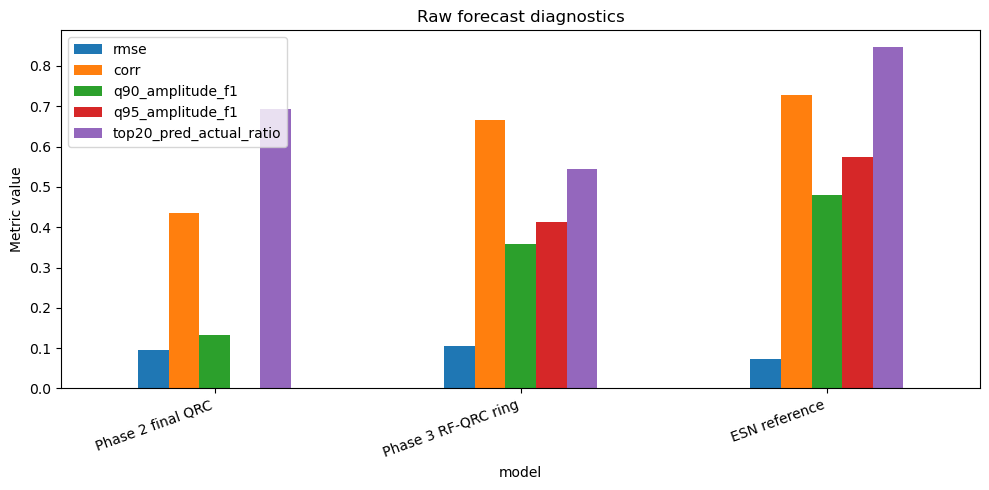

Saved: /Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility/results/figures/phase3_clean_raw_forecast_diagnostics.png


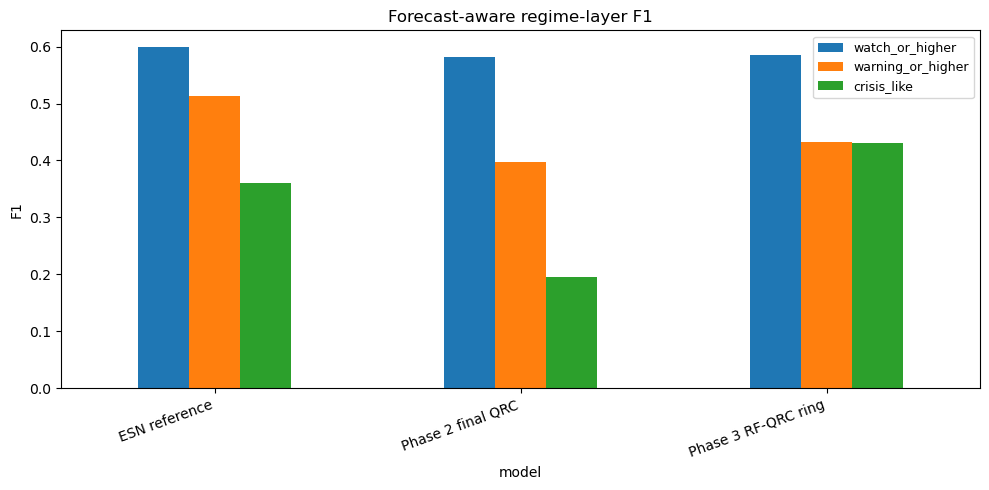

Saved: /Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility/results/figures/phase3_clean_regime_layer_f1.png


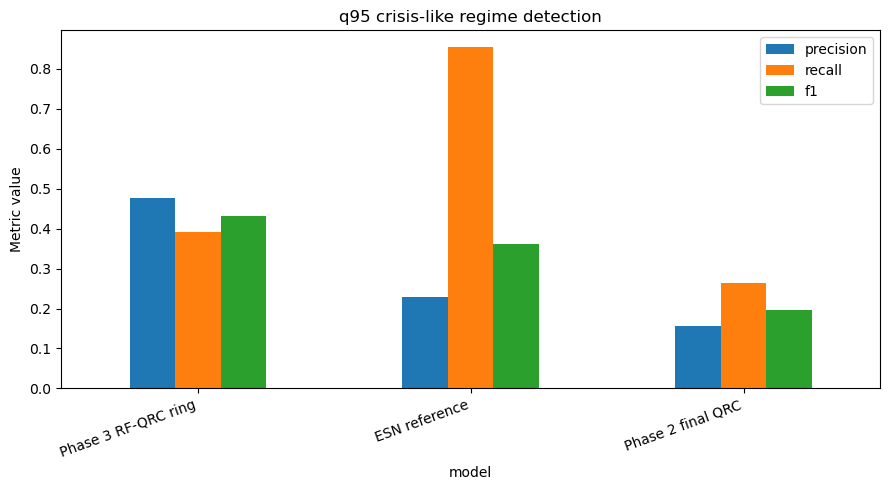

Saved: /Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility/results/figures/phase3_clean_q95_crisis_precision_recall_f1.png


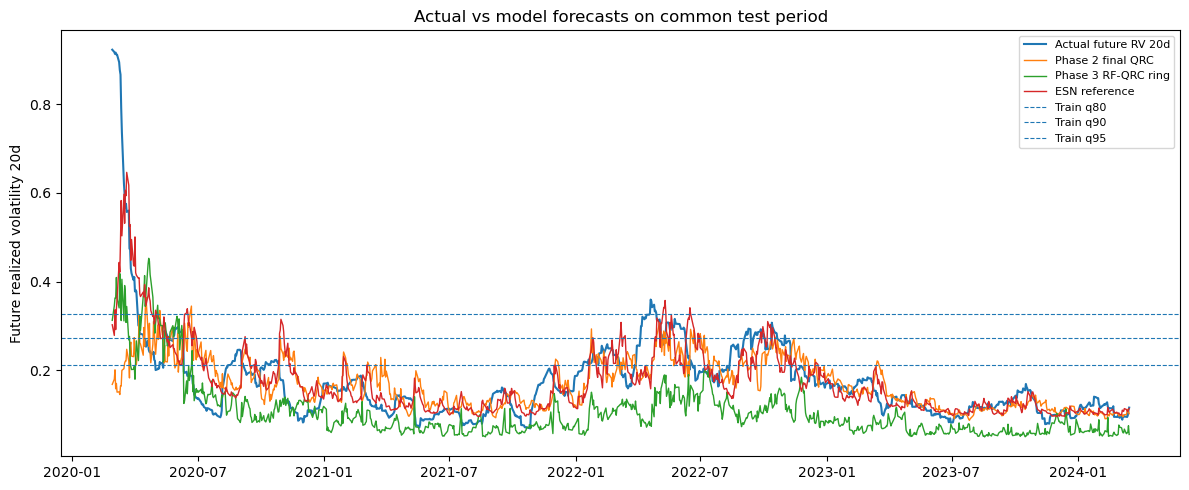

Saved: /Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility/results/figures/phase3_clean_actual_vs_forecasts.png


In [8]:
# Raw diagnostics
plot_raw = raw_comparison[[
    "model", "rmse", "corr", "q90_amplitude_f1", "q95_amplitude_f1", "top20_pred_actual_ratio",
]].set_index("model")
ax = plot_raw.plot(kind="bar", figsize=(10, 5))
ax.set_title("Raw forecast diagnostics")
ax.set_ylabel("Metric value")
ax.legend(loc="best")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
out = FIG_DIR / "phase3_clean_raw_forecast_diagnostics.png"
plt.savefig(out, dpi=200)
plt.show()
print("Saved:", out)

# Regime F1
plot_regime = main_regime_comparison.pivot_table(index="model", columns="signal", values="f1")
plot_regime = plot_regime[["watch_or_higher", "warning_or_higher", "crisis_like"]]
ax = plot_regime.plot(kind="bar", figsize=(10, 5))
ax.set_title("Forecast-aware regime-layer F1")
ax.set_ylabel("F1")
ax.legend(loc="best", fontsize=9)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
out = FIG_DIR / "phase3_clean_regime_layer_f1.png"
plt.savefig(out, dpi=200)
plt.show()
print("Saved:", out)

# q95 precision/recall/F1 focus
q95_focus = main_regime_comparison[main_regime_comparison["signal"].eq("crisis_like")][[
    "model", "precision", "recall", "f1"
]].set_index("model")
ax = q95_focus.plot(kind="bar", figsize=(9, 5))
ax.set_title("q95 crisis-like regime detection")
ax.set_ylabel("Metric value")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
out = FIG_DIR / "phase3_clean_q95_crisis_precision_recall_f1.png"
plt.savefig(out, dpi=200)
plt.show()
print("Saved:", out)

# Actual vs forecasts
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(merged_raw["date"], merged_raw[TARGET], label="Actual future RV 20d", linewidth=1.5)
ax.plot(merged_raw["date"], merged_raw[qrc_col], label="Phase 2 final QRC", linewidth=1.0)
ax.plot(merged_raw["date"], merged_raw[rf_col], label="Phase 3 RF-QRC ring", linewidth=1.0)
ax.plot(merged_raw["date"], merged_raw[esn_col], label="ESN reference", linewidth=1.0)
for label, thr in [("q80", thresholds["q80"]), ("q90", thresholds["q90"]), ("q95", thresholds["q95"] )]:
    ax.axhline(thr, linestyle="--", linewidth=0.8, label=f"Train {label}")
ax.set_title("Actual vs model forecasts on common test period")
ax.set_ylabel("Future realized volatility 20d")
ax.legend(loc="upper right", fontsize=8)
fig.tight_layout()
out = FIG_DIR / "phase3_clean_actual_vs_forecasts.png"
fig.savefig(out, dpi=200)
plt.show()
print("Saved:", out)

## 8. Saved outputs

In [10]:
print("Saved tables:")
for name in [
    "phase3_clean_raw_forecast_comparison.csv",
    "phase3_clean_regime_counts.csv",
    "phase3_clean_full_regime_layer_evaluation.csv",
    "phase3_clean_main_regime_layer_comparison.csv",
]:
    print(" ", TABLE_DIR / name)

print("Saved figures:")
for name in [
    "phase3_clean_raw_forecast_diagnostics.png",
    "phase3_clean_regime_layer_f1.png",
    "phase3_clean_q95_crisis_precision_recall_f1.png",
    "phase3_clean_actual_vs_forecasts.png",
]:
    print(" ", FIG_DIR / name)

Saved tables:
  /Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility/results/tables/phase3_clean_raw_forecast_comparison.csv
  /Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility/results/tables/phase3_clean_regime_counts.csv
  /Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility/results/tables/phase3_clean_full_regime_layer_evaluation.csv
  /Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility/results/tables/phase3_clean_main_regime_layer_comparison.csv
Saved figures:
  /Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility/results/figures/phase3_clean_raw_forecast_diagnostics.png
  /Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Qua